# Dominican Film Industry — Exploratory Data Analysis

**Author:** Jorge Doiany Peguero Almonte  
**GitHub:** [jorgedoiany](https://github.com/jorgedoiany)  
**Dataset:** `01_movies.csv`  
**Period:** 2018–2025  
**Last updated:** 2025

---

## Overview

This notebook presents an exploratory data analysis (EDA) of the Dominican Republic film industry, covering 300+ productions registered between 2018 and 2025.

The goal is to uncover patterns and trends in local film production, including output volume, genre distribution, co-production dynamics, language, distribution status, and key industry players.

This analysis serves as the foundation for the **Dominican Film Industry Executive Dashboard**, built with Python and Streamlit.

---

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Dataset Overview](#2-dataset-overview)
3. [Missing Values Analysis](#3-missing-values-analysis)
4. [Production Trends](#4-production-trends)
5. [Genre Analysis](#5-genre-analysis)
6. [Co-production Analysis](#6-co-production-analysis)
7. [Distribution & Status](#7-distribution--status)
8. [Key Industry Players](#8-key-industry-players)
9. [Budget Analysis](#9-budget-analysis)
10. [Additional Analysis](#10-additional-analysis)
11. [Key Findings & Conclusions](#11-key-findings--conclusions)

## 1. Setup & Data Loading

In [1]:
# --- Standard libraries ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# --- Display settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# --- Plot style ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


### Load Dataset

In [2]:
# Load dataset
df = pd.read_csv('../data/01_movies.csv', sep=';', encoding='utf-8')

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)

Dataset loaded: 321 rows x 16 columns


,movie_id,movie_slug,title,production_year,release_year,genre,duration_min,coproduction_country,status,director,screenplay_author,production_company,short_synopsis,synopsis_source,approx_budget,original_language
0,MOV-0001,DO-2018-inesperadamente-lucia,Inesperadamente Lucia,2018,NaN,comedy,95,DO,in_production,Carlos Waddis Jáquez,Alejandro Andújar|Ettore Trombin,"Yuquita Films, SRL","Luca y Javier, dos amigos extranjeros viven en...",imdb,65546366.00,spanish
1,MOV-0002,DO-2020-tumba-y-quema,Tumba y Quema,2020,2023.00,documentary,90,DO,released,José María Cabral González,José María Cabral González,"Grupo Trukemer, SRL",Un documental sobre la deforestación dentro de...,imdb,37538231.00,spanish
2,MOV-0003,DO-2019-1979,1979,2019,NaN,drama,85,DO,unknown,Ronni Oscar Castillo Alcántara,Emmanuel De Jesús Galán De León,"Pilón Productions, SRL",NaN,pending,39534545.97,spanish
3,MOV-0004,DO-2019-atravesando-el-jordan,Atravesando El Jordán,2019,2020.00,drama,85,DO,released,Alan Augusto Nadal Piantini,Alan Augusto Nadal Piantini,"Pilón Productions, SRL","Jordan, un adolescente amante del baloncesto a...",imdb,26073164.47,spanish
4,MOV-0005,DO-2020-20-billones,20 Billones,2020,NaN,documentary,90,DO,unknown,Oliver Ernesto Olivo Batista,Enrique Darwin Caraballo Beloso,"Educa Films, SRL",NaN,pending,61809568.05,spanish
5,MOV-0006,DO-2020-100-anos-en-movimiento,100 Años En Movimiento,2020,2023.00,documentary,90,DO,released,Andrés Curbelo Baccino,Andrés Curbelo Baccino,"Cacique Productions, SRL",Una visión reveladora que muestra la realidad ...,cinemadominicano,45068242.00,spanish
6,MOV-0007,DO-2020-aventura-historica,Aventura Histórica,2020,2024.00,sci-fi,100,DO,released,Luis Carlos Llosa Urquidi,Luis Carlos Llosa Urquidi|Pablo Ricardo Vazque...,"Aventura Histórica Films, SRL",NaN,pending,99456916.00,spanish
7,MOV-0008,DO-2019-bantu-mama,Bantu Mama,2019,2022.00,drama,86,DO,released,Iván Herrera Beato,Iván Herrera Beato|Clarisse Michelle Albrecht,"Point Barre, SRL",Una francesa de origen africano logra escapar ...,filmaffinity,49896389.00,spanish
8,MOV-0009,DO-2019-con-un-pie-aqui-y-el-otro-alla,Con Un Pie Aquí y El Otro Allá,2019,NaN,documentary,90,DO,in_production,Hans Christians García García,Hans Christians García García,"Hannah Films, SRL",NaN,pending,41279417.81,spanish
9,MOV-0010,DO-2020-cuarencena,Cuarencena,2020,2023.00,comedy,121,DO,released,David Emmanuel Maler Baquero,David Emmanuel Maler Baquero,"Producciones Guayacanes 005, SRL",La armonía se desmorona entre 7 amigos en una ...,filmaffinity,76901622.00,spanish


## 2. Dataset Overview

A quick look at the structure, data types, and basic statistics of the dataset.

In [3]:
# Shape and columns
print(f"Shape: {df.shape[0]} movies × {df.shape[1]} columns")
print(f"\nColumns:\n")
for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")

Shape: 321 movies × 16 columns

Columns:

  - movie_id (str)
  - movie_slug (str)
  - title (str)
  - production_year (int64)
  - release_year (float64)
  - genre (str)
  - duration_min (int64)
  - coproduction_country (str)
  - status (str)
  - director (str)
  - screenplay_author (str)
  - production_company (str)
  - short_synopsis (str)
  - synopsis_source (str)
  - approx_budget (float64)
  - original_language (str)


In [4]:
# Basic statistics
df.describe(include='all')

,movie_id,movie_slug,title,production_year,release_year,genre,duration_min,coproduction_country,status,director,screenplay_author,production_company,short_synopsis,synopsis_source,approx_budget,original_language
count,321,321,321,321.00,97.00,321,321.00,321,321,321,101,320,122,321,320.00,321
unique,321,321,321,NaN,NaN,34,NaN,11,6,222,91,208,122,11,NaN,1
top,MOV-0001,DO-2018-inesperadamente-lucia,Inesperadamente Lucia,NaN,NaN,documentary,NaN,DO,unknown,José María Cabral González,José Ramón Alamá Núñez,"Sky Films, SRL","Luca y Javier, dos amigos extranjeros viven en...",pending,NaN,spanish
freq,1,1,1,NaN,NaN,150,NaN,300,130,7,3,8,1,200,NaN,321
mean,NaN,NaN,NaN,2022.22,2023.85,NaN,87.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53869817.65,NaN
std,NaN,NaN,NaN,1.98,1.35,NaN,10.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32105090.99,NaN
min,NaN,NaN,NaN,2016.00,2020.00,NaN,70.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5995797.37,NaN
25%,NaN,NaN,NaN,2021.00,2023.00,NaN,80.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29062046.10,NaN
50%,NaN,NaN,NaN,2022.00,2024.00,NaN,90.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46138547.52,NaN
75%,NaN,NaN,NaN,2024.00,2025.00,NaN,90.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70475626.94,NaN


## 3. Missing Values Analysis

Understanding data completeness is critical before building any visualization or model. Columns with high missing rates may need to be excluded or imputed.

In [5]:
# Missing values summary
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing = missing[missing['missing_count'] > 0]

print(f"{len(missing)} columns have missing values:\n")
print(missing.to_string())

5 columns have missing values:

                    missing_count  missing_pct
release_year                  224        69.78
screenplay_author             220        68.54
short_synopsis                199        61.99
approx_budget                   1         0.31
production_company              1         0.31


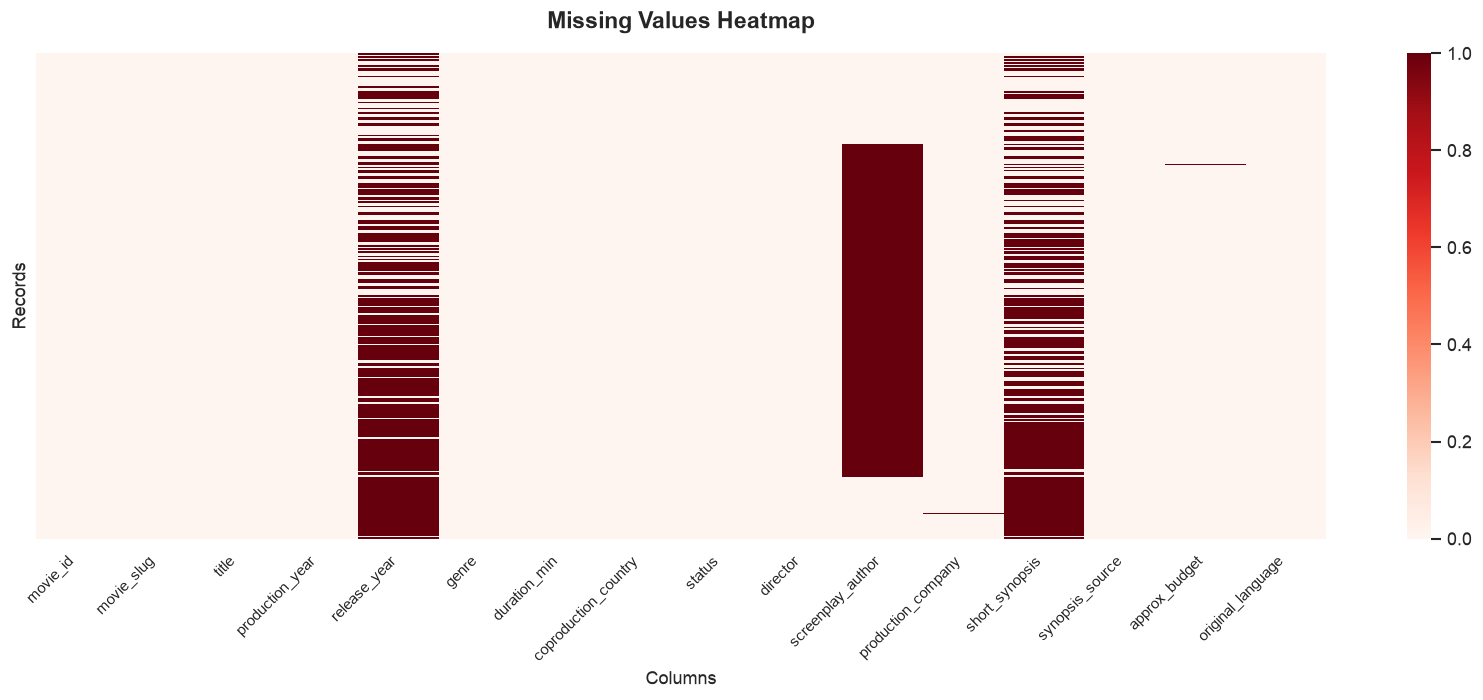

In [6]:
# Heatmap of missing values
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    df.isnull(),
    cbar=True,
    cmap='Reds',
    yticklabels=False,
    ax=ax
)

ax.set_title('Missing Values Heatmap', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Columns', fontsize=11)
ax.set_ylabel('Records', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Production Trends

Analyzing how Dominican film production has evolved year over year from 2018 to 2025.

In [7]:
# Movies per year
movies_per_year = df['production_year'].value_counts().sort_index()

fig = px.bar(
    x=movies_per_year.index,
    y=movies_per_year.values,
    title='Dominican Film Production by Year (2018–2025)',
    labels={'x': 'Year', 'y': 'Number of Films'},
)
fig.update_traces(marker_color='#1f77b4')
fig.update_layout(showlegend=False)
fig.show()

print(f"\nPeak year: {movies_per_year.idxmax()} ({movies_per_year.max()} films)")
print(f"Lowest year: {movies_per_year.idxmin()} ({movies_per_year.min()} films)")


Peak year: 2022 (68 films)
Lowest year: 2016 (1 films)


## 5. Genre Analysis

Since a film can belong to multiple genres (pipe-separated values), we explode the genre column to analyze each genre independently.

In [8]:
# Explode genres (pipe-separated)
genres = (
    df['genre']
    .dropna()
    .str.split('|')
    .explode()
    .astype('string')
    .str.strip()
)
genre_counts = genres.value_counts()

fig = px.bar(
    x=genre_counts.values,
    y=genre_counts.index,
    orientation='h',
    title='Film Count by Genre',
    labels={'x': 'Number of Films', 'y': 'Genre'},
    color=genre_counts.values,
    color_continuous_scale='Teal'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    height=700
)
fig.show()

## 6. Co-production Analysis

Examining international co-production partnerships and their frequency. Films with only `DO` in the `coproduction_country` field are considered 100% Dominican productions.

In [9]:
# Co-production vs 100% Dominican
df['is_coproduction'] = df['coproduction_country'].apply(
    lambda x: 'Co-production' if isinstance(x, str) and '|' in x else 'Dominican Only'
)

coprod_counts = df['is_coproduction'].value_counts()

fig = px.pie(
    values=coprod_counts.values,
    names=coprod_counts.index,
    title='Dominican Only vs. Co-productions',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.show()

In [10]:
# Top co-production countries
countries = df['coproduction_country'].dropna().str.split('|').explode()
countries = countries[countries != 'DO']
country_counts = countries.value_counts().head(10)

fig = px.bar(
    x=country_counts.index,
    y=country_counts.values,
    title='Top Co-production Partner Countries',
    labels={'x': 'Country (ISO)', 'y': 'Number of Films'},
    color=country_counts.values,
    color_continuous_scale='Oranges'
)
fig.show()

## 7. Distribution & Status

Understanding the current status of Dominican productions — how many have been released, are in production, on streaming platforms, etc.

In [11]:
# Status distribution
status_counts = df['status'].value_counts()

fig = px.pie(
    values=status_counts.values,
    names=status_counts.index,
    title='Film Status Distribution',
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.show()

## 8. Key Industry Players

Identifying the most prolific directors and production companies in the Dominican film industry.

In [12]:
# Top 10 directors
top_directors = df['director'].value_counts().head(10)

fig = px.bar(
    x=top_directors.values,
    y=top_directors.index,
    orientation='h',
    title='Top 10 Most Prolific Directors',
    labels={'x': 'Number of Films', 'y': 'Director'},
    color=top_directors.values,
    color_continuous_scale='Purples'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [13]:
# Top 10 production companies
top_companies = df['production_company'].value_counts().head(10)

fig = px.bar(
    x=top_companies.values,
    y=top_companies.index,
    orientation='h',
    title='Top 10 Most Active Production Companies',
    labels={'x': 'Number of Films', 'y': 'Production Company'},
    color=top_companies.values,
    color_continuous_scale='Greens'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

## 9. Budget Analysis

Analyzing the approximate budget distribution across Dominican productions. Note: This field has a high missing rate — findings should be interpreted with caution.

In [14]:
# Budget distribution (only available values)
budget_df = df[df['approx_budget'].notna()]

print(f"Budget data available for {len(budget_df)} of {len(df)} films ({len(budget_df)/len(df)*100:.1f}%)\n")

fig = px.histogram(
    budget_df,
    x='approx_budget',
    title='Budget Distribution (DOP)',
    labels={'approx_budget': 'Approximate Budget (DOP)'},
    color_discrete_sequence=['#636EFA']
)
fig.show()

print(f"\nAverage budget: RD${budget_df['approx_budget'].mean():,.0f}")
print(f"Median budget:  RD${budget_df['approx_budget'].median():,.0f}")
print(f"Max budget:     RD${budget_df['approx_budget'].max():,.0f}")
print(f"Min budget:     RD${budget_df['approx_budget'].min():,.0f}")

Budget data available for 320 of 321 films (99.7%)




Average budget: RD$53,869,818
Median budget:  RD$46,138,548
Max budget:     RD$265,348,823
Min budget:     RD$5,995,797


## 10. Additional Analysis

Exploring numerical variable correlations and film duration distribution.

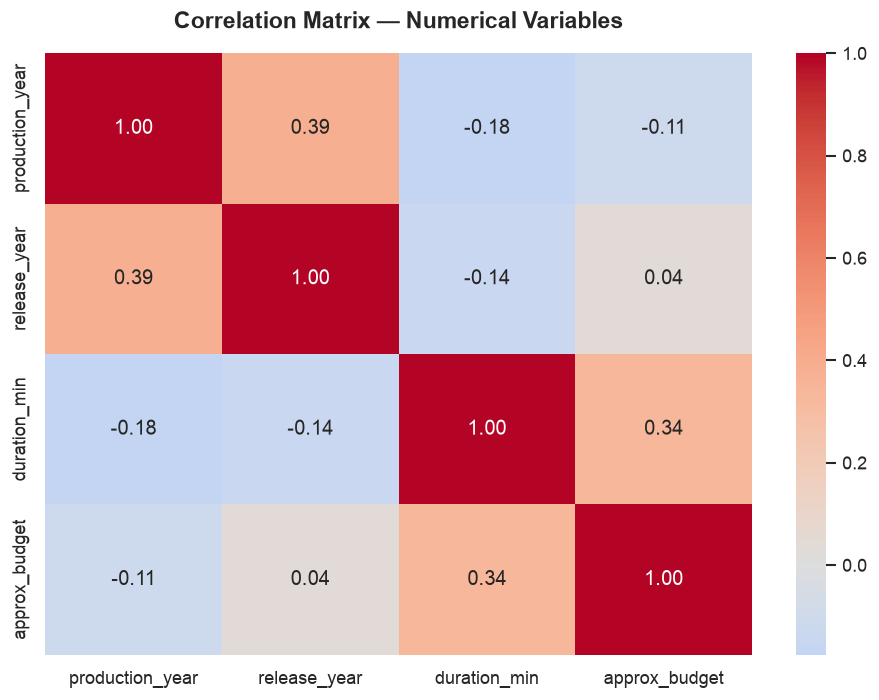

In [15]:
# Correlation matrix for numerical variables
numeric_cols = ['production_year', 'release_year', 'duration_min', 'approx_budget']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Correlation Matrix — Numerical Variables',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [16]:
# Average budget per year
budget_year = df[df['approx_budget'].notna()].groupby('production_year')['approx_budget'].mean().reset_index()

fig = px.line(
    budget_year,
    x='production_year',
    y='approx_budget',
    title='Average Production Budget by Year (DOP)',
    labels={'production_year': 'Year', 'approx_budget': 'Average Budget (DOP)'},
    markers=True
)
fig.update_traces(line_color='#1f77b4', marker_color='#1f77b4')
fig.show()

film_type
Non-Documentary    168
Documentary        152
Name: count, dtype: int64


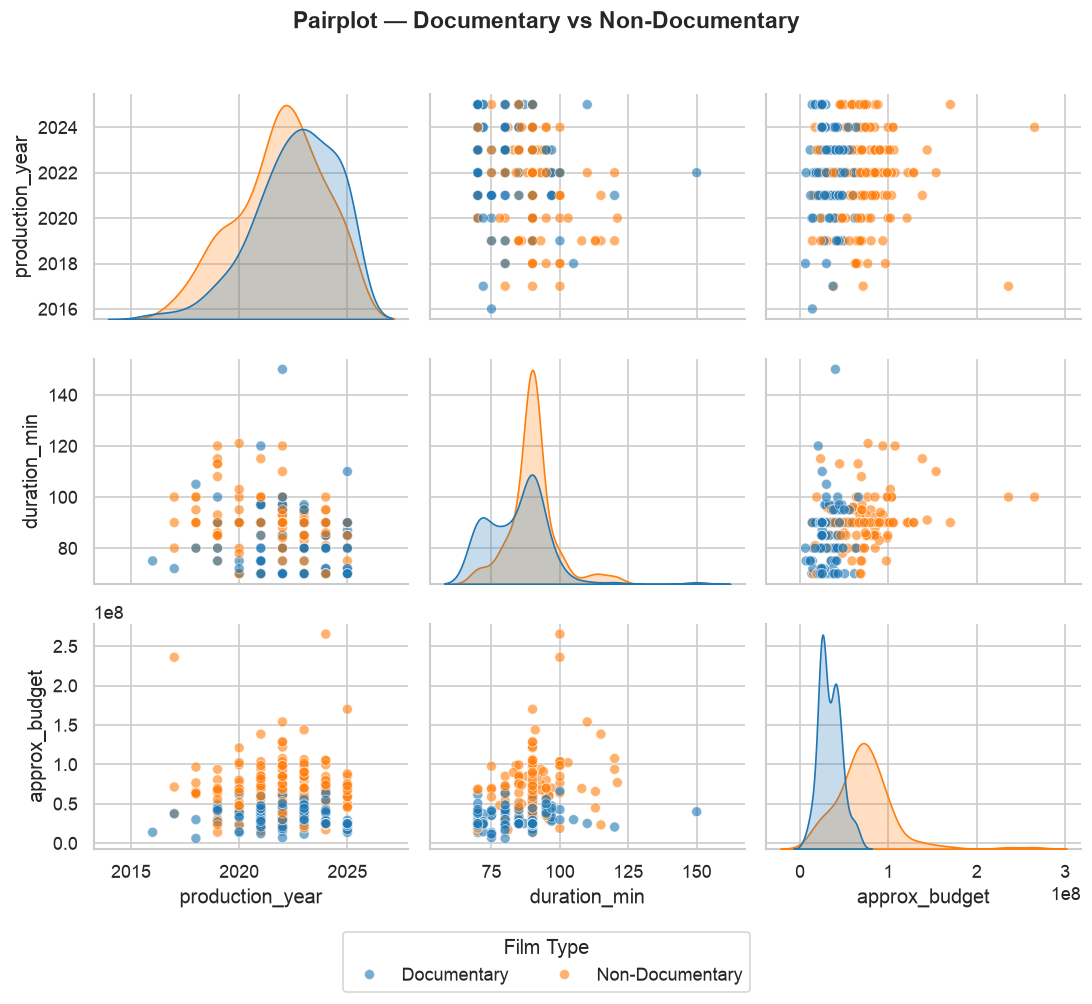

In [17]:
# Classify films as Documentary vs Non-Documentary
df['film_type'] = df['genre'].apply(
    lambda x: 'Documentary' if isinstance(x, str) and 'documentary' in x.lower() else 'Non-Documentary'
)

# Pairplot
numeric_cols = ['production_year', 'duration_min', 'approx_budget']
pairplot_df = df[numeric_cols + ['film_type']].dropna()

# Verify classification
print(pairplot_df['film_type'].value_counts())

g = sns.pairplot(
    pairplot_df,
    hue='film_type',
    hue_order=['Documentary', 'Non-Documentary'],
    palette={'Documentary': '#1f77b4', 'Non-Documentary': '#ff7f0e'},
    plot_kws={'alpha': 0.6},
    diag_kind='kde'
)

# Move legend to bottom
assert g.legend is not None, "Pairplot legend was not created"
handles = g.legend.legend_handles
labels = [t.get_text() for t in g.legend.get_texts()]
g.legend.remove()
g.figure.legend(
    handles=handles,
    labels=labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    title='Film Type',
    frameon=True
)

g.figure.suptitle('Pairplot — Documentary vs Non-Documentary',
                  fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 11. Key Findings & Conclusions

### Production
- Dominican film production peaked in 2022 with 68 films, reflecting a post-pandemic recovery and growth in the local industry.
- The dataset covers 300+ productions between 2018 and 2025, with 2016 representing the lowest output (1 film), likely due to limited historical records rather than actual low production.
- 40% of productions (130 films) have an unknown status, highlighting the lack of systematic public tracking of Dominican film projects.

### Genres
- Documentary is the dominant genre with 152 films, representing the majority of Dominican film production.
- Drama is the second most common genre with 81 films, followed by comedy (38) and thriller (15).
- The presence of niche genres such as docufiction, docudrama, and tragicomedy reflects the diversity of Dominican film production.

### Co-productions
- The majority of Dominican films are 100% national productions.
- Spain, Mexico and the United States are the most frequent co-production partners.

### Industry Players
- José María Cabral González, Pablo José Lozano Hernández and Miguel Vásquez Brazoban are the most prolific directors with 7 films each.
- Sky Films SRL leads production company output with 8 films, followed by Metro Films SRL (7) and multiple companies tied at 6.
- The average production budget is RD$53,869,818 with a maximum of RD$265,348,823, reflecting significant investment in the sector.

### Budget & Duration
- The 2017 budget peak (RD$95M average) likely reflects a small number of high-budget productions skewing the average upward.
- From 2018 onwards budgets stabilized between RD$48M and RD$60M, suggesting a maturing industry with more consistent investment levels.
- The declining trend from 2022 to 2025 may reflect economic pressures or a shift toward lower-budget documentary productions.
- duration_min and approx_budget show the strongest meaningful correlation (0.34), suggesting longer films tend to have higher budgets.
- Both documentary and non-documentary films receive comparable investment levels, with budgets overlapping significantly.

### Data Quality Notes
- release_year (69.78%), screenplay_author (68.54%), and short_synopsis (61.99%) have high missing rates due to limited public availability of this information for Dominican productions.
- approx_budget and production_company are nearly complete with only 0.31% missing values each.

---

*This EDA was conducted as part of the Dominican Film Industry Dashboard project.*
*Author: Jorge Doiany Peguero Almonte | GitHub: jorgedoiany*